In [1]:
import logging, warnings
import numpy as np, pandas as pd
from pathlib import Path
from scipy.stats import spearmanr, ConstantInputWarning
from tqdm import tqdm
from umap import UMAP
from dtaidistance import dtw, dtw_visualisation as dtwvis
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import pathlib
import importlib
import sys

from src.utils import iter_dataset_dirs, load_json
from src.plot_style import apply_plot_style
from src.visualization import plot_mts_corr_density, plot_spi_space_individual, plot_pca, plot_tsne, plot_umap, plot_mts_heatmap
from src.utils import project_root
import numpy as np
import pandas as pd
from src.utils import project_root
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_pca, plot_umap, plot_tsne, plot_spi_space_individual, plot_spi_space_recursive

apply_plot_style()
logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")
warnings.simplefilter("ignore", ConstantInputWarning)


/Users/wedi0306/Code/mts-spi-study-cluster/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


#### Scoping the MTS Generator

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from src.generators import generate_sin_mts_mother
from src.visualization import plot_mts_heatmap

M, T = 9, 300
rng = np.random.default_rng(42)

# Generate one instance of each regime class
cases = {
    "fixed-linear":       dict(regime="fixed", n_linear=M, n_monotonic=0),
    "fixed-monotonic":    dict(regime="fixed", n_linear=0, n_monotonic=M),
    "fixed-nonmonotonic": dict(regime="fixed", n_linear=0, n_monotonic=0),
    "random":             dict(regime="random", _regime_seed=0),
}

data = {
    name: generate_sin_mts_mother(M=M, T=T, noise_std=0.05, ar1_a=0.8, ar1_noise_std=1.0, rng=42+i, **params)
    for i, (name, params) in enumerate(cases.items())
}

for name, X in data.items():
    plot_mts_heatmap(X.T, title=name, vmin=-1.5, vmax=1.5)


In [ ]:
from src.generators.linear import _SIN_INTERVALS

# One shared mother, all three transforms applied
rng = np.random.default_rng(0)
m = np.zeros(T)
for t in range(1, T):
    m[t] = 0.8 * m[t-1] + rng.normal(0, 1.0)
m_bar = (m - m.min()) / (m.max() - m.min())

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
colors = {"linear": "steelblue", "monotonic": "darkorange", "non-monotonic": "crimson"}
for ax, (reg, (a, b)) in zip(axes, _SIN_INTERVALS.items()):
    y = np.sin((b - a) * m_bar + a)
    ax.plot(y, lw=0.8, color=colors[reg], label=reg)
    ax.legend(loc="upper right", fontsize=9)
    ax.set_ylim(-1.2, 1.2)
axes[0].set_title("Same AR(1) mother → three transforms")
plt.tight_layout()


#### [placeholder]

#### @ Sun 22-Mar: triple $r(r, \rho)$, $r(r, \mathrm{MI})$, $r(\rho, \mathrm{MI})$

##### Strongest: $\uparrow$ SNR - `ar1_a:0.95`; `noist_std=0.02`

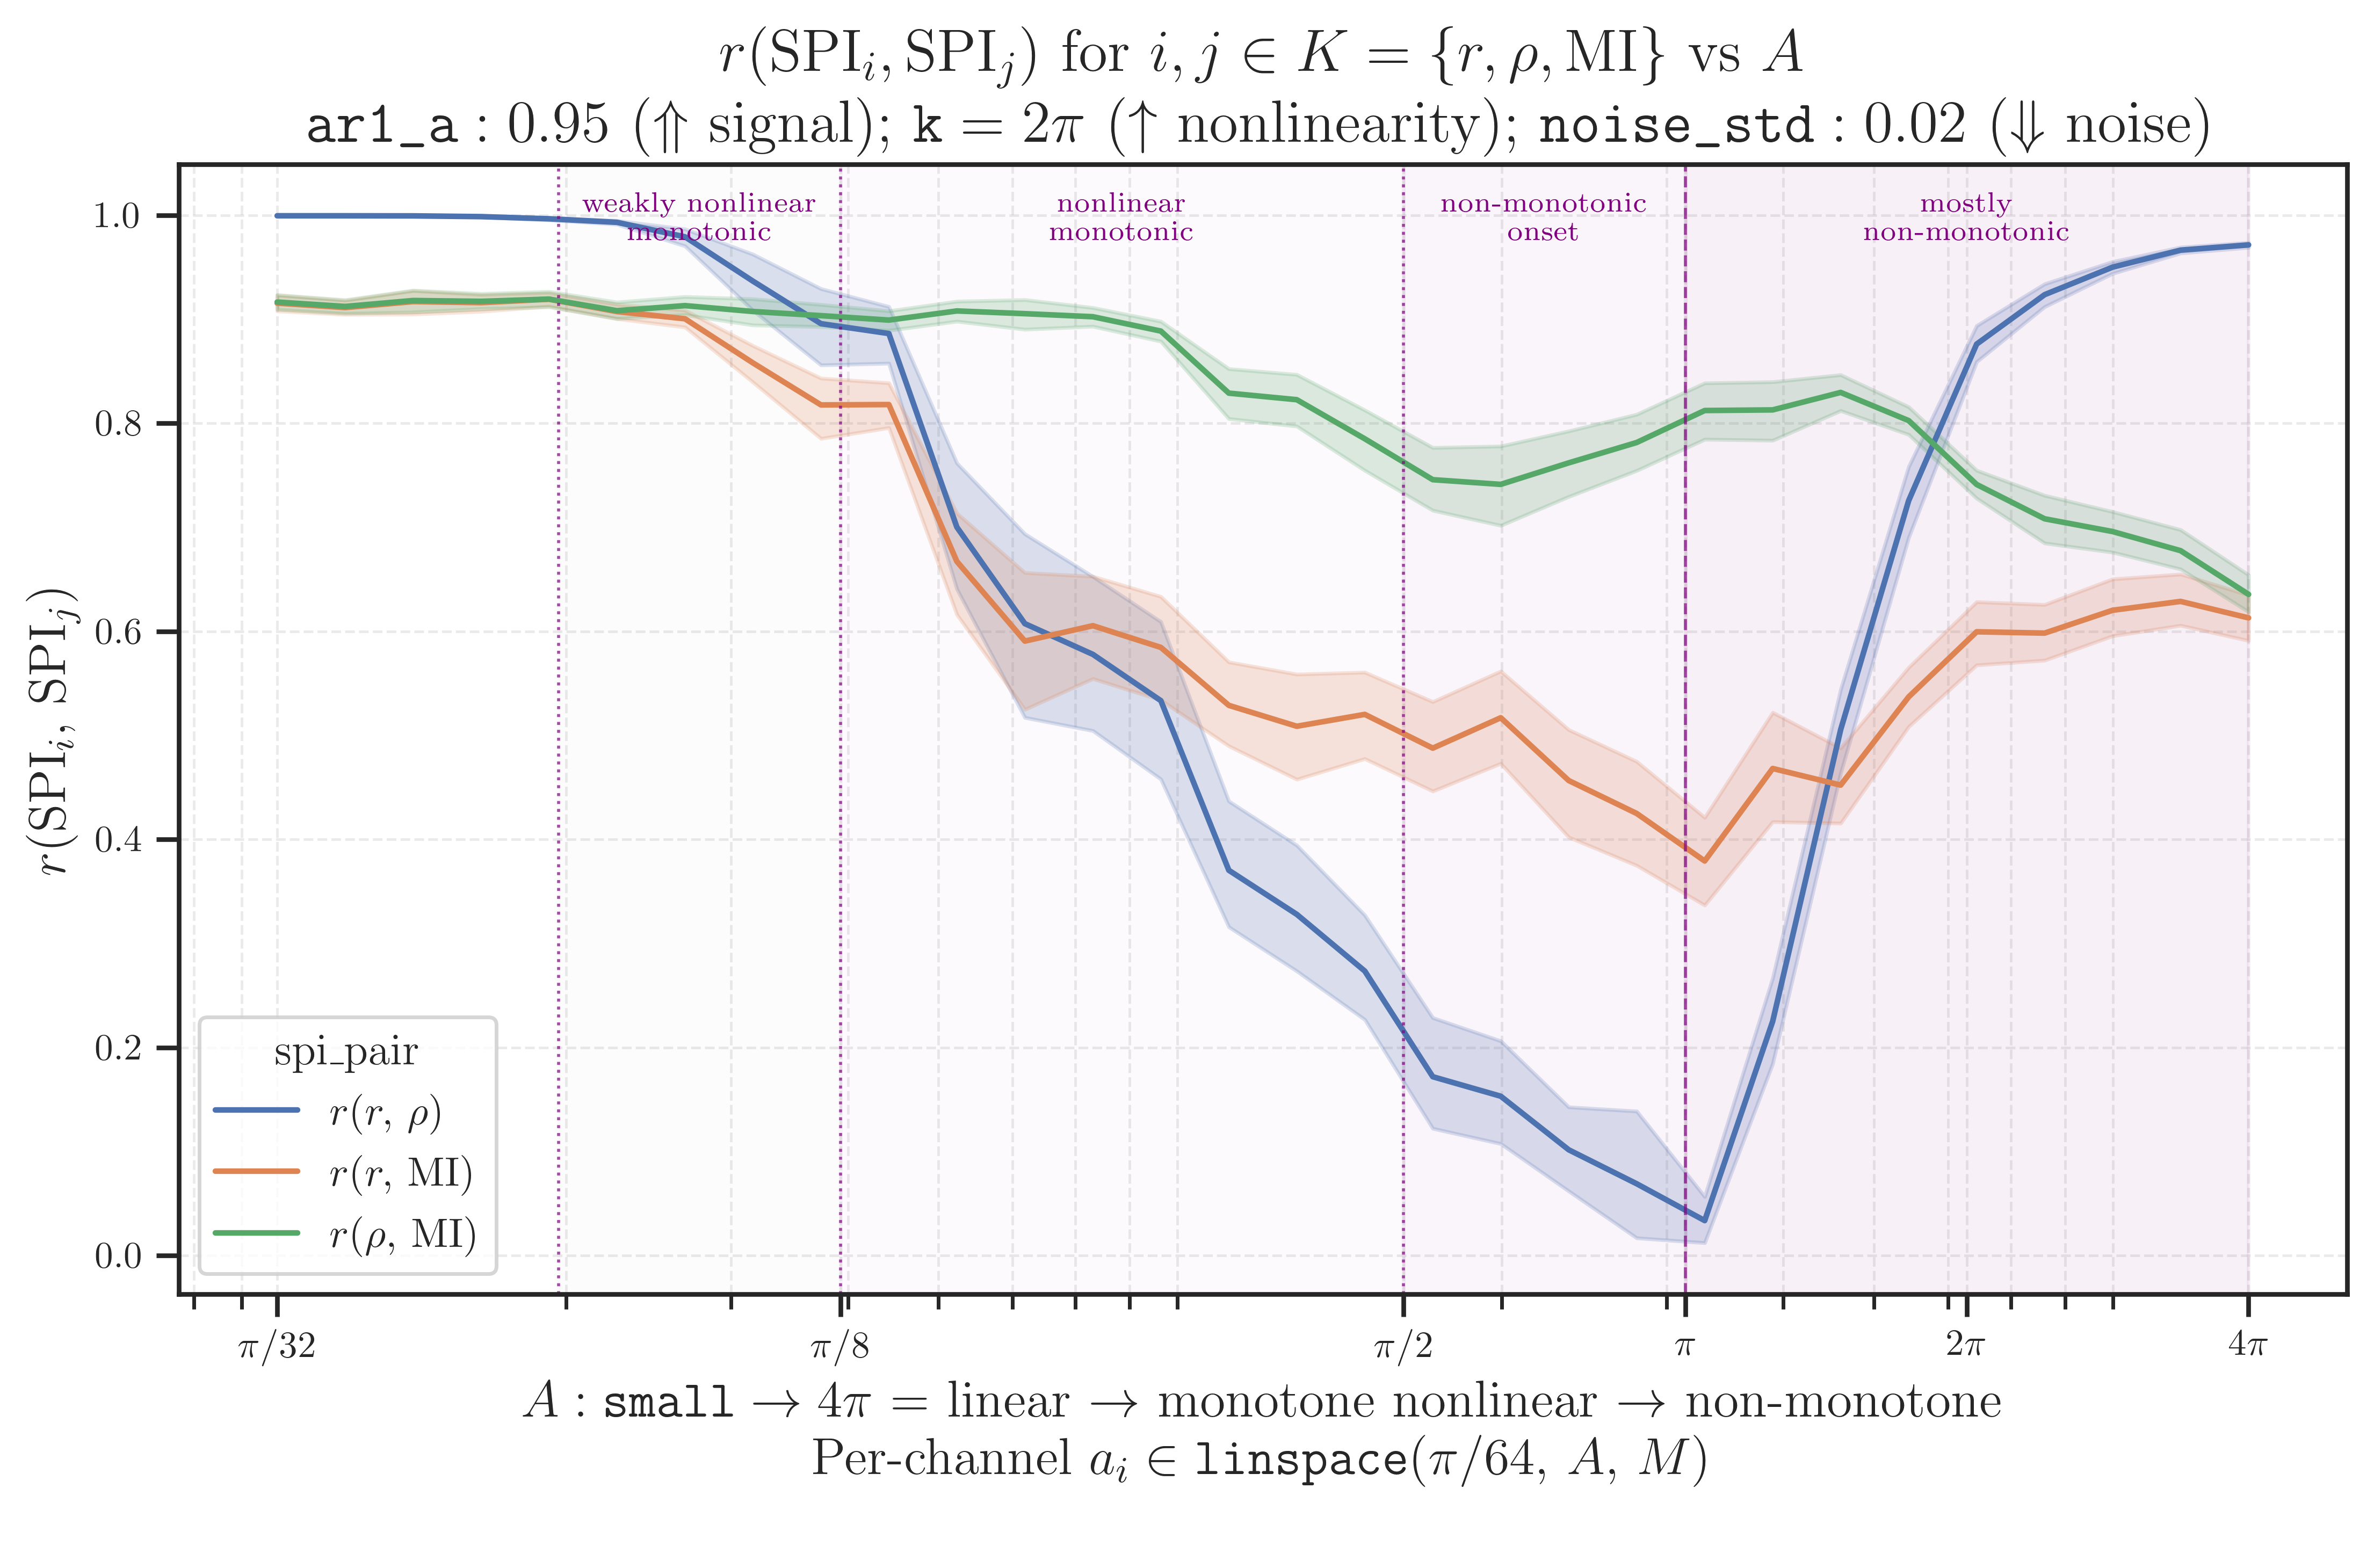

In [7]:
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_spi_corr_meta
from src.plot_style import apply_plot_style
from src.utils import project_root
import matplotlib.pyplot as plt
import numpy as np

apply_plot_style()

spi_pairs = [
    ["cov_EmpiricalCovariance", "spearmanr"],
    ["cov_EmpiricalCovariance", "mi_kraskov_NN-4"],
    ["spearmanr",               "mi_kraskov_NN-4"],
]
pair_labels = [
    r"$r(r,\,\rho)$",
    r"$r(r,\,\mathrm{MI})$",
    r"$r(\rho,\,\mathrm{MI})$",
]

fig, ax = plt.subplots(1, 1, figsize=(9, 6),dpi=500)
ax.grid(True, which="both", axis="both", lw=0.7, linestyle="--", alpha=0.4)

base = "data/r_rho_mi/"
# dataset = "260322_g-tanhsin_k-2pi_noise_0.05_a-0.9_T2000"
dataset = "260323_g-tanhsin_k-2pi_noise_0.02_a-0.95_T2000"


plot_spi_corr_meta(
    project_root() / base / dataset,
    spi_pairs=spi_pairs,
    x_key="A",
    pair_labels=pair_labels,
    metric="pearson",
    title=r"$r(\mathrm{SPI}_i,\mathrm{SPI}_j)$ for $i,j \in K=\{r, \rho, \mathrm{MI}\}$ vs $A$" "\n" 
            r"$\texttt{ar1_a}:0.95$ ($\Uparrow$ signal); $\texttt{k}=2 \pi$ ($\uparrow$ nonlinearity); $\texttt{noise_std}:0.02$ ($\Downarrow$ noise)",
    # r"[$k{=}1$, $M{=}20$, linspace, $T{=}2000$, 30 instances]",
    xlabel=(
        r"$A: \texttt{small} \to 4 \pi$ = linear $\to$ monotone nonlinear $\to$ non-monotone" "\n"
        r"Per-channel $a_i \in \mathtt{linspace}(\pi/64,\, A,\, M)$" "\n"
    ),
    ylabel=r"$r(\mathrm{SPI}_i,\, \mathrm{SPI}_j)$",
    ax=ax,
 )

ax.set_xscale("log")

pi_ticks  = [np.pi/32, np.pi/8, np.pi/2, np.pi, 2*np.pi, 4*np.pi]
pi_labels = [r"$\pi/32$", r"$\pi/8$", r"$\pi/2$", r"$\pi$", r"$2\pi$", r"$4\pi$"]
ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels)

for x_val, ls in [
    (np.pi / 16, ":"),
    (np.pi / 8, ":"),
    (np.pi / 2, ":"),
    (np.pi,     "--"),
]:
    ax.axvline(x_val, color="purple", linestyle=ls, lw=0.8, alpha=0.7)

for x_mid, lbl in [
    (np.sqrt(np.pi/16 * np.pi/8),  r"weakly nonlinear" "\n" r"monotonic"),
    (np.sqrt(np.pi/8 * np.pi/2),  r"nonlinear" "\n" r"monotonic"),
    (np.sqrt(np.pi/2 * np.pi),    r"non-monotonic" "\n" r"onset"),
    (np.sqrt(np.pi * 4*np.pi),    r"mostly" "\n" r"non-monotonic"),
]:
    ax.text(x_mid, 0.975, lbl, ha="center", va="top", fontsize=7.5,
            color="purple", transform=ax.get_xaxis_transform())

ax.axvspan(np.pi/16, np.pi/8, color="purple", alpha=0.01)
ax.axvspan(np.pi/8, np.pi/2, color="purple", alpha=0.02)
ax.axvspan(np.pi/2, np.pi, color="purple", alpha=0.04)
ax.axvspan(np.pi, 4*np.pi, color="purple", alpha=0.06)


fig.tight_layout()
plt.show()


##### SPI-SPI space scatterplots for above run

In [6]:
# SPI-SPI space scatter grid: {r, rho, MI} triplet across the nonlinearity sweep
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_spi_space_individual_embed_properties
from src.plot_style import apply_plot_style
from src.utils import project_root
import matplotlib.pyplot as plt
import numpy as np

apply_plot_style()

spi_pairs = [
    ["cov_EmpiricalCovariance", "spearmanr"],
    ["cov_EmpiricalCovariance", "mi_kraskov_NN-4"],
    ["spearmanr",               "mi_kraskov_NN-4"],
]

base = "data/r_rho_mi/260323_g-tanhsin_k-2pi_noise_0.02_a-0.95_T2000"

# A values ~ {pi/32, pi/8, pi/4, pi/2, pi, 3pi/2, 2pi, 4pi}
# matched to nearest class in the 30-point log-spaced sweep
class_rows = [
    ("A-0.031pi_L",         r"$A \approx \pi/32$"),
    ("A-0.119pi_L-M",       r"$A \approx \pi/8$"),
    ("A-0.233pi_L-M",       r"$A \approx \pi/4$"),
    ("A-0.537pi_L-M-NM",    r"$A \approx \pi/2$"),
    ("A-1.049pi_L-M-NM",    r"$A \approx \pi$"),
    ("A-1.466pi_L-M-NM",    r"$A \approx 3\pi/2$"),
    ("A-2.048pi_L-M-NM",    r"$A \approx 2\pi$"),
    ("A-4.000pi_L-M-NM",    r"$A \approx 4\pi$"),
]

n_rows, n_cols = len(class_rows), len(spi_pairs)
fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows),
    squeeze=False, dpi=500,
)

for r, (cls, row_label) in enumerate(class_rows):
    dataset_path = project_root() / base / cls / "M20_T2000_I0"
    for c, spis in enumerate(spi_pairs):
        plot_spi_space_individual_embed_properties(
            dataset_path=dataset_path,
            spis=spis,
            ax=axes[r, c],
            thresh_linear=np.pi / 8,
            thresh_monotonic=np.pi / 2,
            color_by_type=True,
            alpha=0.5,
            metric="pearson",
            identity=False,
        )
    axes[r, 0].set_ylabel(f"{row_label}\n{axes[r, 0].get_ylabel()}")

fig.tight_layout(w_pad=4, h_pad=2)
plt.show()


##### Next strongest: `ar1_a=0.9`; `noise_std=0.05`

In [ ]:
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_spi_corr_meta
from src.plot_style import apply_plot_style
from src.utils import project_root
import matplotlib.pyplot as plt
import numpy as np

apply_plot_style()

spi_pairs = [
    ["cov_EmpiricalCovariance", "spearmanr"],
    ["cov_EmpiricalCovariance", "mi_kraskov_NN-4"],
    ["spearmanr",               "mi_kraskov_NN-4"],
]
pair_labels = [
    r"$r(r,\,\rho)$",
    r"$r(r,\,\mathrm{MI})$",
    r"$r(\rho,\,\mathrm{MI})$",
]

fig, ax = plt.subplots(1, 1, figsize=(9, 6),dpi=500)
ax.grid(True, which="both", axis="both", lw=0.7, linestyle="--", alpha=0.4)

base = "data/r_rho_mi/"
dataset = "260322_g-tanhsin_k-2pi_noise_0.05_a-0.9_T2000"
# dataset = "260323_g-tanhsin_k-2pi_noise_0.02_a-0.95_T2000"


plot_spi_corr_meta(
    project_root() / base / dataset,
    spi_pairs=spi_pairs,
    x_key="A",
    pair_labels=pair_labels,
    metric="pearson",
    title=r"$r(\mathrm{SPI}_i,\mathrm{SPI}_j)$ for $i,j \in K=\{r, \rho, \mathrm{MI}\}$ vs $A$" "\n" 
            r"$\texttt{ar1_a}:0.90$ ($\uparrow$ signal); $\texttt{k}=2 \pi$ ($\uparrow$ nonlinearity); $\texttt{noise_std}:0.05$ ($\downarrow$ noise)",
    # r"[$k{=}1$, $M{=}20$, linspace, $T{=}2000$, 30 instances]",
    xlabel=(
        r"$A: \texttt{small} \to 4 \pi$ = linear $\to$ monotone nonlinear $\to$ non-monotone" "\n"
        r"Per-channel $a_i \in \mathtt{linspace}(\pi/64,\, A,\, M)$" "\n"
    ),
    ylabel=r"$r(\mathrm{SPI}_i,\, \mathrm{SPI}_j)$",
    ax=ax,
)

ax.set_xscale("log")

pi_ticks  = [np.pi/32, np.pi/8, np.pi/2, np.pi, 2*np.pi, 4*np.pi]
pi_labels = [r"$\pi/32$", r"$\pi/8$", r"$\pi/2$", r"$\pi$", r"$2\pi$", r"$4\pi$"]
ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels)

for x_val, ls in [
    (np.pi / 16, ":"),
    (np.pi / 8, ":"),
    (np.pi / 2, ":"),
    (np.pi,     "--"),
]:
    ax.axvline(x_val, color="purple", linestyle=ls, lw=0.8, alpha=0.7)

for x_mid, lbl in [
    (np.sqrt(np.pi/16 * np.pi/8),  r"weakly nonlinear" "\n" r"monotonic"),
    (np.sqrt(np.pi/8 * np.pi/2),  r"nonlinear" "\n" r"monotonic"),
    (np.sqrt(np.pi/2 * np.pi),    r"non-monotonic" "\n" r"onset"),
    (np.sqrt(np.pi * 4*np.pi),    r"mostly" "\n" r"non-monotonic"),
]:
    ax.text(x_mid, 0.975, lbl, ha="center", va="top", fontsize=7.5,
            color="purple", transform=ax.get_xaxis_transform())

ax.axvspan(np.pi/16, np.pi/8, color="purple", alpha=0.01)
ax.axvspan(np.pi/8, np.pi/2, color="purple", alpha=0.02)
ax.axvspan(np.pi/2, np.pi, color="purple", alpha=0.04)
ax.axvspan(np.pi, 4*np.pi, color="purple", alpha=0.06)


fig.tight_layout()
plt.show()


##### Moderate: `ar1_a=0.8`; `noise_std=0.1`

In [ ]:
import importlib
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_spi_corr_meta
from src.plot_style import apply_plot_style
from src.utils import project_root
import matplotlib.pyplot as plt
import numpy as np

apply_plot_style()

spi_pairs = [
    ["cov_EmpiricalCovariance", "spearmanr"],
    ["cov_EmpiricalCovariance", "mi_kraskov_NN-4"],
    ["spearmanr",               "mi_kraskov_NN-4"],
]
pair_labels = [
    r"$r(r,\,\rho)$",
    r"$r(r,\,\mathrm{MI})$",
    r"$r(\rho,\,\mathrm{MI})$",
]

fig, ax = plt.subplots(1, 1, figsize=(9, 6),dpi=500)
ax.grid(True, which="both", axis="both", lw=0.7, linestyle="--", alpha=0.4)

base = "data/r_rho_mi/"
# dataset = "260322_g-tanhsin"
# dataset = "260322_g-tanhsin_k-pi"
# dataset = "260323_g-tanhsin_k-10_noise-0.4_a-0.8_ranA"
# dataset = "260323_g-tanhsin_k-10_noise-0.05_a-0.8"
# dataset = "260323_g-tanhsin_k-pi_noise-0.2_a-0.6_ranA_T1000"
# dataset = "260323_g-tanhsin_k-pi_noise-0.2_a-0.6_ranA_T1000-linA"
dataset = "260322_g-tanhsin_k-1_noise_0.1_a-0.8_T2000"
# dataset = "260322_g-tanhsin_k-2pi_noise_0.1_a-0.8_T2000"



plot_spi_corr_meta(
    project_root() / base / dataset,
    spi_pairs=spi_pairs,
    x_key="A",
    pair_labels=pair_labels,
    metric="pearson",
    title=r"$r(\mathrm{SPI}_i,\mathrm{SPI}_j)$ for $i,j \in K=\{r, \rho, \mathrm{MI}\}$ vs $A$" "\n" 
            r"$\texttt{ar1_a}:0.80$ ($\uparrow$ signal); $\texttt{k}=2 \pi$ ($\uparrow$ nonlinearity); $\texttt{noise_std}:0.10$ ($\downarrow$ noise)",
    # r"[$k{=}1$, $M{=}20$, linspace, $T{=}2000$, 30 instances]",
    xlabel=(
        r"$A: \texttt{small} \to 4 \pi$ = linear $\to$ monotone nonlinear $\to$ non-monotone" "\n"
        r"Per-channel $a_i \in \mathtt{linspace}(\pi/64,\, A,\, M)$" "\n"
    ),
    ylabel=r"$r(\mathrm{SPI}_i,\, \mathrm{SPI}_j)$",
    ax=ax,
)

ax.set_xscale("log")

pi_ticks  = [np.pi/32, np.pi/8, np.pi/2, np.pi, 2*np.pi, 4*np.pi]
pi_labels = [r"$\pi/32$", r"$\pi/8$", r"$\pi/2$", r"$\pi$", r"$2\pi$", r"$4\pi$"]
ax.set_xticks(pi_ticks)
ax.set_xticklabels(pi_labels)

for x_val, ls in [
    (np.pi / 16, ":"),
    (np.pi / 8, ":"),
    (np.pi / 2, ":"),
    (np.pi,     "--"),
]:
    ax.axvline(x_val, color="purple", linestyle=ls, lw=0.8, alpha=0.7)

for x_mid, lbl in [
    (np.sqrt(np.pi/16 * np.pi/8),  r"weakly nonlinear" "\n" r"monotonic"),
    (np.sqrt(np.pi/8 * np.pi/2),  r"nonlinear" "\n" r"monotonic"),
    (np.sqrt(np.pi/2 * np.pi),    r"non-monotonic" "\n" r"onset"),
    (np.sqrt(np.pi * 4*np.pi),    r"mostly" "\n" r"non-monotonic"),
]:
    ax.text(x_mid, 0.975, lbl, ha="center", va="top", fontsize=7.5,
            color="purple", transform=ax.get_xaxis_transform())

ax.axvspan(np.pi/16, np.pi/8, color="purple", alpha=0.01)
ax.axvspan(np.pi/8, np.pi/2, color="purple", alpha=0.02)
ax.axvspan(np.pi/2, np.pi, color="purple", alpha=0.04)
ax.axvspan(np.pi, 4*np.pi, color="purple", alpha=0.06)


fig.tight_layout()
plt.show()

In [ ]:
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_spi_space_individual_embed, plot_spi_space_individual_embed_properties
from src.plot_style import apply_plot_style
import matplotlib.pyplot as plt

apply_plot_style()

spi_pairs = [
    ["cov_EmpiricalCovariance", "spearmanr"],
    ["cov_EmpiricalCovariance", "mi_kraskov_NN-4"],
    ["spearmanr", "mi_kraskov_NN-4"],
]

# base = "data/r_rho_mi/260322_g-tanhsin_k-2pi_noise_0.1_a-0.8_T2000"
# base = "data/r_rho_mi/260322_g-tanhsin_k-2pi_noise_0.05_a-0.9_T2000" #strong, weaker
base = "data/r_rho_mi/260323_g-tanhsin_k-2pi_noise_0.02_a-0.95_T2000" #strongest


datasets = [
    f"{base}/A-0.031pi_L/M20_T2000_I1",
    # f"{base}/A-0.031pi_L/M20_T2000_I1",
    # f"{base}/A-0.101pi_L-M/M20_T2000_I0",
    # f"{base}/A-0.101pi_L-M/M20_T2000_I1",
    f"{base}/A-0.167pi_L-M/M20_T2000_I1",
    # f"{base}/A-0.167pi_L-M/M20_T2000_I1",
    # f"{base}/A-4pi/M20_T2000_I0",
    f"{base}/A-1.466pi_L-M-NM/M20_T2000_I1",
    f"{base}/A-4.000pi_L-M-NM/M20_T2000_I1",
    # f"{base}/A-8pi/M20_T2000_I1",
]

n_rows, n_cols = len(datasets), len(spi_pairs)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), 
                         sharex="col", sharey="col",
                         squeeze=False, dpi=500)

for r, ds in enumerate(datasets):
    for c, spis in enumerate(spi_pairs):
        plot_spi_space_individual_embed_properties(
            dataset_path=project_root() / ds,
            spis=spis,
            ax=axes[r, c],
            color_by_type=True,       # or False
            thresh_linear=np.pi / 16,  # adjust to investigate
            alpha=0.4,
            metric="pearson",
            identity=False,
        )

fig.tight_layout(w_pad=3, h_pad=3)
# legend stuff
from collections import OrderedDict
handles_dict = OrderedDict()
for ax in axes.flat:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in handles_dict:
            handles_dict[l] = h
fig.legend(handles_dict.values(), handles_dict.keys(), title="channel pair",
           loc="upper right", bbox_to_anchor=(1.2, 0.91))
plt.show()



### Experiment 0.0: 02-Mar-26

In [ ]:
# import importlib
# import src.visualization
# importlib.reload(src.visualization)
# from src.visualization import plot_spi_corr_sweep
# from src.plot_style import apply_plot_style
# import matplotlib.pyplot as plt

# apply_plot_style()

# SPI_LABELS = {
#     "cov_EmpiricalCovariance": r"$r$",
#     "spearmanr": r"$\rho$",
#     "mi_kraskov_NN-4": r"$\mathrm{MI}$",
# }
# PVAR_LABELS = {
#     "l":  "Proportion of Linear Channels (l / M)",
#     "m":  "Proportion of Monotonic Channels (m / M)",
#     "nm": "Proportion of Non-Monotonic Channels (nm / M)",
# }

# dataset = "r_rho_260302_143446"
# spi_pairs = [
#     ["cov_EmpiricalCovariance", "spearmanr"]
# ]
# proportion_vars = ["m"]

# fig, axes = plt.subplots(len(proportion_vars), len(spi_pairs), figsize=(6 * len(spi_pairs), 4 * len(proportion_vars)), squeeze=False)

# for r, pvar in enumerate(proportion_vars):
#     for c, spi_pair in enumerate(spi_pairs):
#         sx, sy = SPI_LABELS[spi_pair[0]], SPI_LABELS[spi_pair[1]]
#         plot_spi_corr_sweep(
#             project_root() / "data" / dataset,
#             spi_pair=spi_pair,
#             folder_template="l-<l>_m-<m>_nm-<nm>",
#             x_var=pvar,
#             hue=False,
#             title=f"corr({sx}, {sy})  vs.  {pvar}",
#             ylabel=f"corr({sx}, {sy})",
#             xlabel=r"Monotonic channels $m$",
#             ax=axes[r, c],
#         )

# fig.tight_layout()
# plt.show()


In [ ]:
import src.visualization
importlib.reload(src.visualization)
from src.visualization import plot_spi_space_individual_embed, plot_spi_space_individual_embed_properties
from src.plot_style import apply_plot_style
import matplotlib.pyplot as plt

apply_plot_style()

spi_pairs = [
    ["cov_EmpiricalCovariance", "spearmanr"],
    ["cov_EmpiricalCovariance", "mi_kraskov_NN-4"],
    ["spearmanr", "mi_kraskov_NN-4"],
]
# base = "data/r_rho_mi/20260305_smooth-6/smooth_A-"
# base = "data/r_rho_mi/260318_tanh-sin/smooth_A-"
# base = "data/r_rho_mi/260318_tanhh-sin_a0.5_M20_linsp-False/smooth_A-"
# base = "data/r_rho_mi/260318_tanh-sin_a0.5_linsp-True_k-2pi/smooth_A-"
# base = "data/r_rho_mi/260318_tanh-sin_a0.5_linsp-True_8pi/smooth_A-"
# base = "data/r_rho_mi/260318_tanh-sin_a0.99_linsp-True_std-low-noise/smooth_A-"
base = "data/r_rho_mi/260318_tanh-sin_k-20/smooth_A-"



datasets = [
    f"{base}pi32/M20_T1000_I0",
    # f"{base}pi32/M20_T1000_I1",
    f"{base}pi2/M20_T1000_I0",
    # f"{base}pi2/M20_T1000_I1",
    # f"{base}pi/M20_T1000_I0",
    # f"{base}pi/M20_T1000_I1",
    # f"{base}4pi/M20_T1000_I0",
    # f"{base}4pi/M20_T1000_I1",
    f"{base}8pi/M20_T1000_I0",
    # f"{base}8pi/M20_T1000_I1",
]

n_rows, n_cols = len(datasets), len(spi_pairs)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), 
                         sharex="col", sharey="col",
                         squeeze=False, dpi=500)

for r, ds in enumerate(datasets):
    for c, spis in enumerate(spi_pairs):
        plot_spi_space_individual_embed_properties(
            dataset_path=project_root() / ds,
            spis=spis,
            ax=axes[r, c],
            color_by_type=True,       # or False
            thresh_linear=np.pi / 16,  # adjust to investigate
            alpha=0.4,
            metric="pearson"
        )


fig.tight_layout()
# legend stuff
from collections import OrderedDict
handles_dict = OrderedDict()
for ax in axes.flat:
    for h, l in zip(*ax.get_legend_handles_labels()):
        if l not in handles_dict:
            handles_dict[l] = h
fig.legend(handles_dict.values(), handles_dict.keys(), title="channel pair",
           loc="upper right", bbox_to_anchor=(1.2, 0.91))
plt.show()



#### Experiment 0.0: Scope

#### End header